# 🎵 Визуализация на Мел-спектрограмите и MFCC по Класове

В този ноутбук разглеждаме двата основни начина за извличане на признаци (features) от нашия аудио сигнал спрямо различните архитектури, които разработваме.

1. **Мел-спектрограма (Mel Spectrogram):** 2D текстура. Високоинформативна, детайлна картина на разпределението на звуковата енергия по честоти във времето. Тя е изключително подходяща за **CNN (Модели за компютърно зрение)**, тъй като конволюционните слоеве отлично улавят локални форми и пространствени зависимости.
2. **MFCC (Съкратено от Mel-Frequency Cepstral Coefficients):** По-компактно представяне на Мел-спектрограмата, при което се премахва излишната корелация между съседните честотни ленти чрез Дискретно косинусово преобразувание (DCT). Тези коефициенти описват "формата" на спектралното разпределение (timbre) във всеки времеви момент. Тъй като MFCC създава по-плътни, де-корелирани вектори (time steps), той е **идеалният вход за рекурентни модели като LSTM**, които анализират дълбоки последователности във времето (последователност от кадри).

In [4]:
import os
import sys
import pandas as pd
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

# Пътища до оригиналните файлове
CSV_PATH = "../data/raw/Urban8k/UrbanSound8K.csv"
AUDIO_DIR = "../data/raw/Urban8k/"

# Зареждане на метаданните
# Тъй като работим с UrbanSound8K, колоната е 'class', а не 'category'!
df = pd.read_csv(CSV_PATH)
print(f"Общ брой файлове: {len(df)}")
print(f"Общ брой класове: {df['class'].nunique()}")

# Взимаме уникалните имена на класове от датасета: 
unique_classes = sorted(df['class'].unique())
print("\nСписък с всички звуци (класове) в UrbanSound8K:")
for i, class_name in enumerate(unique_classes, 1):
    print(f" {i}. {class_name}")
print("-" * 50 + "\n")

Общ брой файлове: 8732
Общ брой класове: 10

Списък с всички звуци (класове) в UrbanSound8K:
 1. air_conditioner
 2. car_horn
 3. children_playing
 4. dog_bark
 5. drilling
 6. engine_idling
 7. gun_shot
 8. jackhammer
 9. siren
 10. street_music
--------------------------------------------------



## Сравнителна галерия: Mel-Spectrogram срещу MFCC

Ще визуализираме по един случаен пример от всеки клас.
За всяка аудио извадка ще генерираме две съседни под-фигури:
- Отляво: **Мел-спектрограма** (за CNN)
- Отдясно: **MFCC коефициенти** (за LSTM)

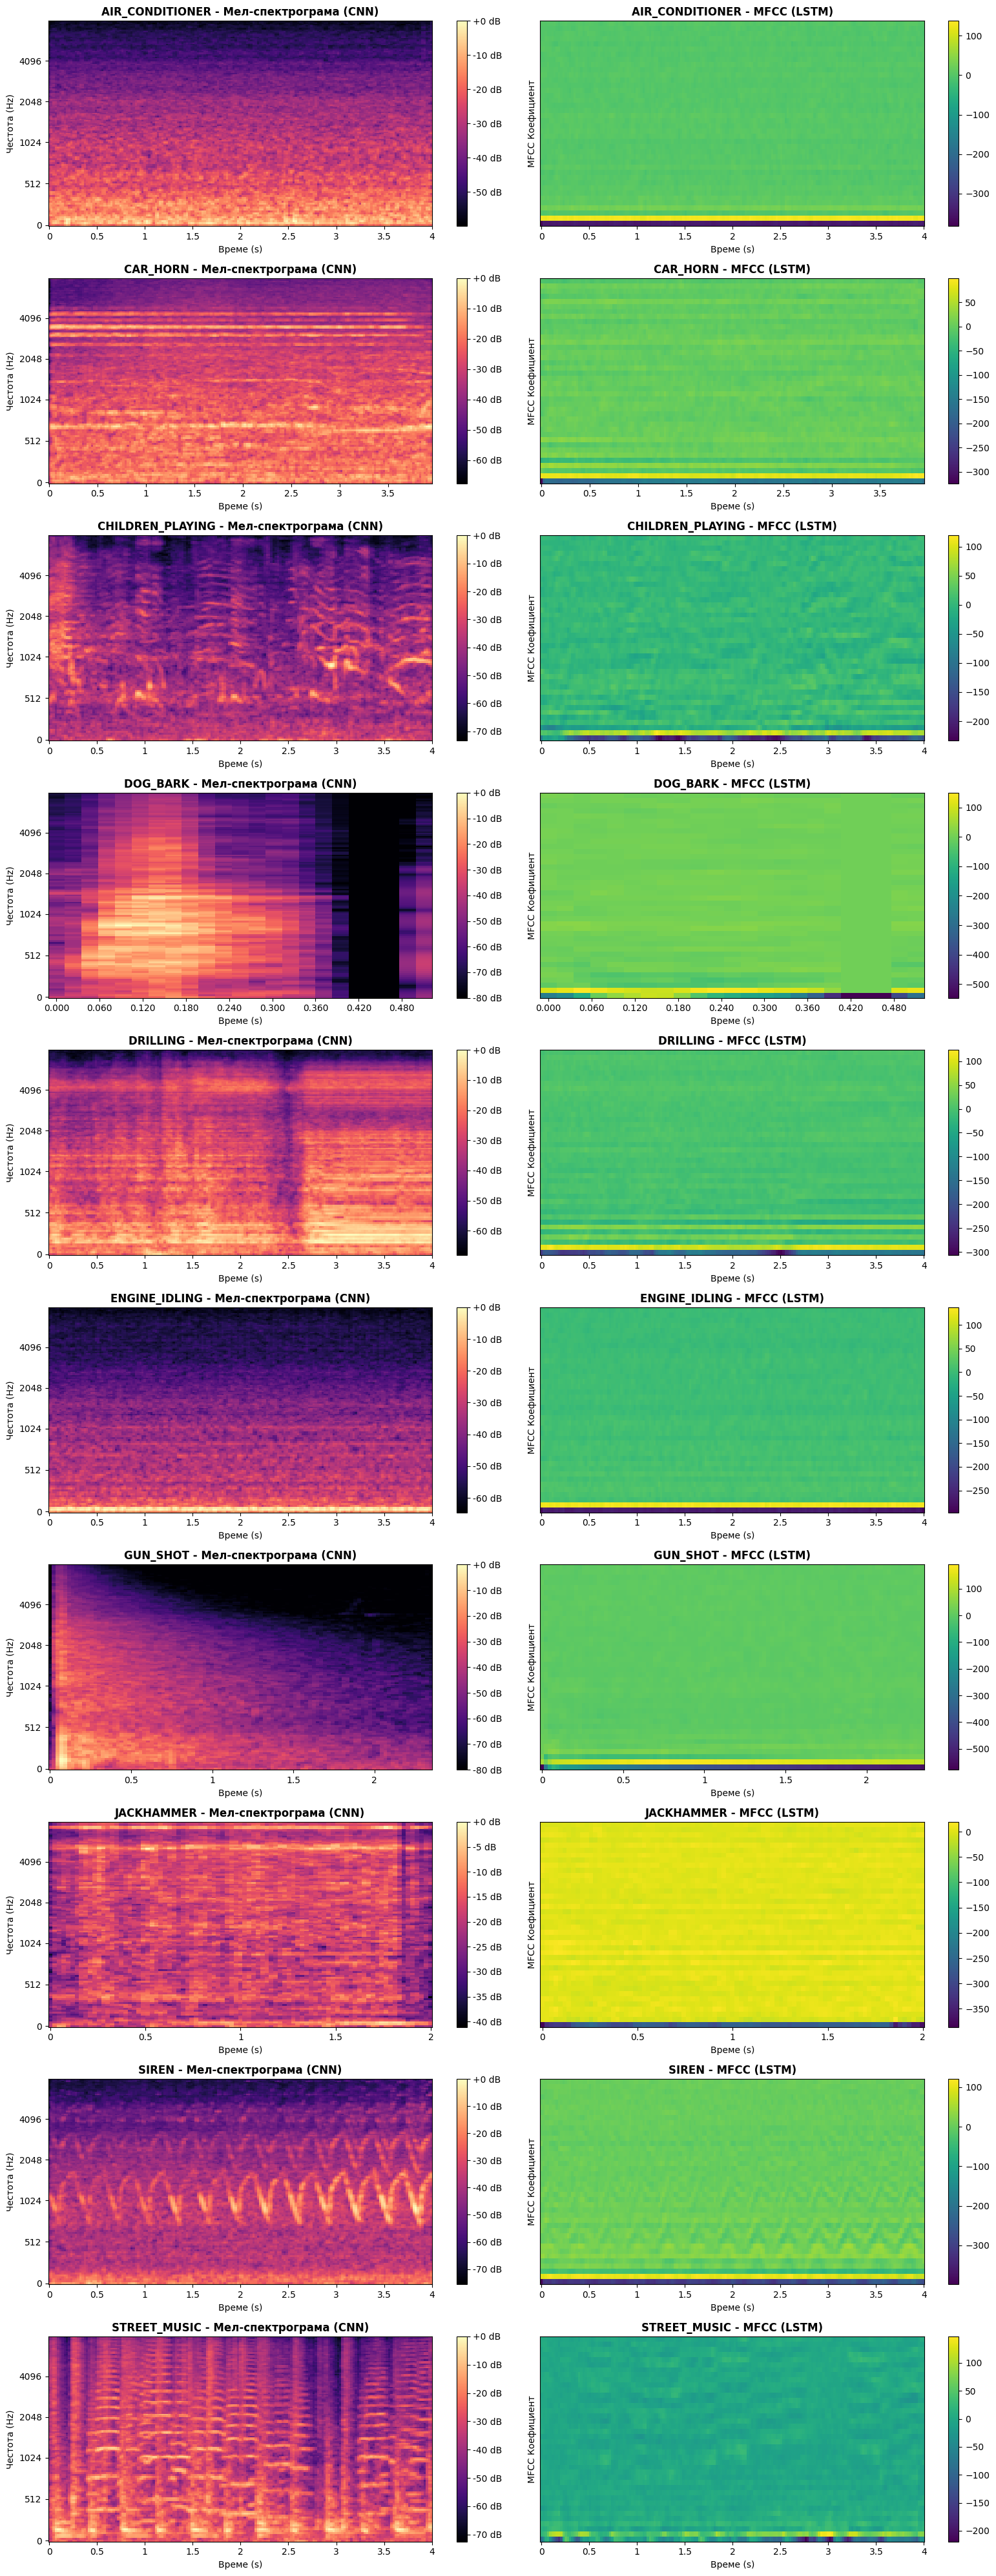

In [5]:
# Настройки за аудиото и feature extraction
target_sample_rate = 22050
n_mels = 128  # За CNN
n_mfcc = 40   # Увеличен брой MFCC коефициенти за по-богата информация за LSTM (стандартно са 13 или 20)

fig, axes = plt.subplots(len(unique_classes), 2, figsize=(16, 4 * len(unique_classes)))

for i, cls in enumerate(unique_classes):
    # 1. Избираме случаен запис от класа
    sample_row = df[df['class'] == cls].sample(1).iloc[0]
    
    # Тъй като UrbanSound8K разпределя файловете в папки (fold1, fold2...)
    # трябва да сглобим правилния път
    fold_dir = f"fold{sample_row['fold']}"
    file_path = os.path.join(AUDIO_DIR, fold_dir, sample_row['slice_file_name'])
    
    # 2. Зареждане на аудиото
    y, sr = librosa.load(file_path, sr=target_sample_rate)
    
    # ===============================
    # ИЗВЛИЧАНЕ ЗА CNN (Мел-спектрограма)
    # ===============================
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, fmax=8000)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    
    # Визуализация на Мел-спектрограмата (лява колона)
    ax_mel = axes[i, 0]
    img_mel = librosa.display.specshow(
        mel_spec_db, sr=sr, x_axis='time', y_axis='mel', fmax=8000, ax=ax_mel, cmap='magma'
    )
    ax_mel.set_title(f"{cls.upper()} - Мел-спектрограма (CNN)", fontsize=12, fontweight='bold')
    ax_mel.set_xlabel('Време (s)')
    ax_mel.set_ylabel('Честота (Hz)')
    fig.colorbar(img_mel, ax=ax_mel, format="%+2.0f dB")

    # ===============================
    # ИЗВЛИЧАНЕ ЗА LSTM (MFCC)
    # ===============================
    # MFCC се пресмята директно върху вече генерираната Мел-спектрограма
    mfccs = librosa.feature.mfcc(S=librosa.power_to_db(mel_spec), n_mfcc=n_mfcc)
    
    # Визуализация на MFCC (дясна колона)
    ax_mfcc = axes[i, 1]
    img_mfcc = librosa.display.specshow(
        mfccs, sr=sr, x_axis='time', ax=ax_mfcc, cmap='viridis'
    )
    ax_mfcc.set_title(f"{cls.upper()} - MFCC (LSTM)", fontsize=12, fontweight='bold')
    ax_mfcc.set_xlabel('Време (s)')
    ax_mfcc.set_ylabel('MFCC Коефициент')
    fig.colorbar(img_mfcc, ax=ax_mfcc)

plt.tight_layout()
plt.show()

### 🧠 Разликата в представянията спрямо моделите

#### 1. Мел-спектрограма (Свързана с архитектурата CNN)
- **Какво виждаме:** Детайлно разпределение на енергията в 128 локални честотни ленти.
- **Предимство:** CNN ядрата (kernels) могат да обхождат това 2D изображение и да активират филтри за специфични форми: плавни криви на сирени, вертикални импулси на стъпки или резки удари на кучешки лай.
- **Ограничение:** Има висока размерност (`128 x time_steps`) и силна корелация между съседните мел-ленти (често енергията прелива плавно от една лента в друга).

#### 2. MFCC (Свързана с архитектурата LSTM)
- **Какво виждаме:** Компресирана версия на 128-те мел-ленти в само 40 (или 13/20) MFCC коефициента. Разпределението изглежда почти като "шум" за човешкото око, тъй като корелацията е математически изчистена.
- **Предимство:** Създава много по-плътни, ортогонални времеви кадри (time steps).  Вместо да обработва високоразмерна 128-пикселова колона, LSTM мрежата приема вектори с размер 40 на всяка стъпка. Липсата на излишна корелация позволява на LSTM клетките (които имат множество gates: forget, input, output) да се фокусират по-лесно върху това *как* точно се променя тембърът на звука във времето.
- **Извод за кода:** Поради тази специфика, в `LSTM_train.py` може да поискаме входният размер `n_feature` на мрежата да бъде `40`, ако решим да я тренираме на MFCC вместо на чисти Мел-спектрограми.